# 肺炎 vs 正常 CXR EDA

`x-ray/data/` 以下の train・eval それぞれの split に含まれる症例について、肺炎 (Pneumonia) が付与された胸部X線と「No Finding」と診断された正常症例を比較します。本ノートブックでは発生頻度、患者/撮影メタデータ、そして対応する画像の違いを可視化していきます。


In [9]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

sns.set_theme(style="whitegrid")
pd.options.display.max_rows = 20


In [10]:
BASE_DIR = Path("/home/kaitech/KaiTech/Medical-Guidelines/x-ray")
DATA_DIR = BASE_DIR / "data"
SPLITS = {
    "train": {
        "labels": DATA_DIR / "train" / "labels.csv",
        "images": DATA_DIR / "train" / "images",
    },
    "eval": {
        "labels": DATA_DIR / "eval" / "labels.csv",
        "images": DATA_DIR / "eval" / "images",
    },
}


def load_split(split_name: str) -> pd.DataFrame:
    meta = SPLITS[split_name]
    df = pd.read_csv(meta["labels"]).copy()
    df["split"] = split_name
    df["labels"] = df["Finding Labels"].fillna("")
    df["has_pneumonia"] = df["labels"].str.contains("Pneumonia", regex=False)
    df["is_normal"] = df["labels"] == "No Finding"
    return df


dfs = [load_split(name) for name in SPLITS]
all_df = pd.concat(dfs, ignore_index=True)
all_df.head()


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,...,Cardiomegaly,Emphysema,Edema,Fibrosis,Pneumonia,Hernia,split,labels,has_pneumonia,is_normal
0,00000032_001.png,Cardiomegaly|Edema|Effusion,1,32,55,F,AP,2500,2048,0.168,...,1,0,1,0,0,0,train,Cardiomegaly|Edema|Effusion,False,False
1,00000032_012.png,Atelectasis|Consolidation|Edema|Pneumonia,12,32,55,F,AP,2500,2048,0.168,...,0,0,1,0,1,0,train,Atelectasis|Consolidation|Edema|Pneumonia,True,False
2,00000032_041.png,Edema|Effusion|Infiltration|Nodule,41,32,55,F,AP,2500,2048,0.168,...,0,0,1,0,0,0,train,Edema|Effusion|Infiltration|Nodule,False,False
3,00000032_045.png,Cardiomegaly|Edema|Effusion|Infiltration,45,32,55,F,AP,2500,2048,0.168,...,1,0,1,0,0,0,train,Cardiomegaly|Edema|Effusion|Infiltration,False,False
4,00000061_003.png,Effusion|Pleural_Thickening,3,61,77,M,PA,3056,2472,0.139,...,0,0,0,0,0,0,train,Effusion|Pleural_Thickening,False,False


## Splitごとの概観

メタデータや画像の違いを掘り下げる前に、各 split で肺炎・正常症例がどの程度出現しているかを把握します。


In [11]:
summary = (
    all_df.groupby("split")
    .agg(
        total=("Image Index", "count"),
        pneumonia_cases=("has_pneumonia", "sum"),
        normal_cases=("is_normal", "sum"),
    )
    .assign(
        pneumonia_rate=lambda d: d["pneumonia_cases"] / d["total"],
        normal_rate=lambda d: d["normal_cases"] / d["total"],
    )
)
summary


,total,pneumonia_cases,normal_cases,pneumonia_rate,normal_rate
split,,,,,
eval,626,185,239,0.295527,0.381789
train,2328,626,855,0.268900,0.367268


/tmp/ipykernel_13361/833356524.py:28: UserWarning: Glyph 30151 (\N{CJK UNIFIED IDEOGRAPH-75C7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13361/833356524.py:28: UserWarning: Glyph 20363 (\N{CJK UNIFIED IDEOGRAPH-4F8B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13361/833356524.py:28: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13361/833356524.py:28: UserWarning: Glyph 21029 (\N{CJK UNIFIED IDEOGRAPH-5225}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13361/833356524.py:28: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13361/833356524.py:28: UserWarning: Glyph 26377 (\N{CJK UNIFIED IDEOGRAPH-6709}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13361/833356524.py:28: UserWarning: Glyph 28961 (\N{CJK UNIFIED IDEOGRAPH-7121}) missin

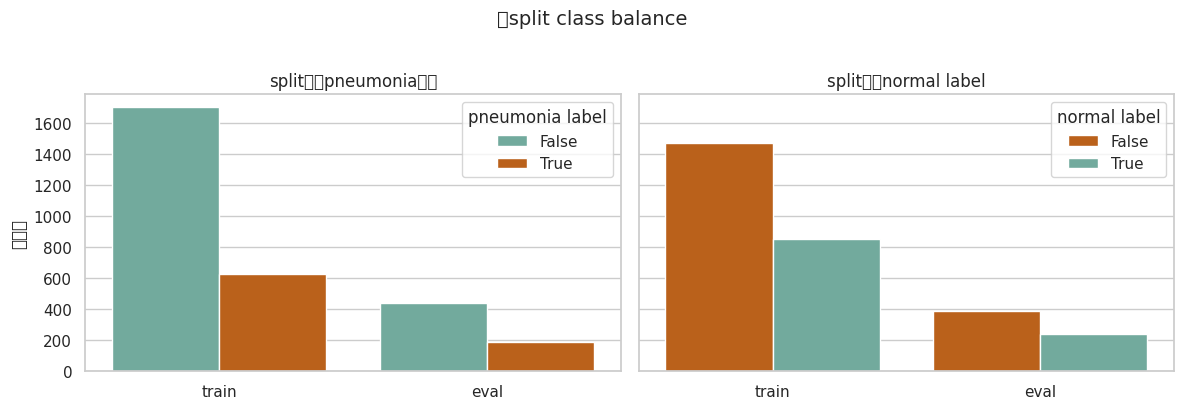

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

sns.countplot(
    data=all_df,
    x="split",
    hue="has_pneumonia",
    palette=["#69b3a2", "#d55e00"],
    ax=ax[0],
)
ax[0].set_title("split別のpneumonia有無")
ax[0].set_ylabel("症例数")
ax[0].set_xlabel("")
ax[0].legend(title="pneumonia label", labels=["False", "True"])

sns.countplot(
    data=all_df,
    x="split",
    hue="is_normal",
    palette=["#d55e00", "#69b3a2"],
    ax=ax[1],
)
ax[1].set_title("split別のnormal label")
ax[1].set_ylabel("")
ax[1].set_xlabel("")
ax[1].legend(title="normal label", labels=["False", "True"])

fig.suptitle("各split class balance", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


## 患者レベルの特徴量

肺炎群と正常群について、年齢・性別などの患者背景および撮影条件（View Position）の違いを比較します。


/tmp/ipykernel_13361/628335604.py:28: UserWarning: Glyph 24180 (\N{CJK UNIFIED IDEOGRAPH-5E74}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13361/628335604.py:28: UserWarning: Glyph 40802 (\N{CJK UNIFIED IDEOGRAPH-9F62}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13361/628335604.py:28: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13361/628335604.py:28: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13361/628335604.py:28: UserWarning: Glyph 32954 (\N{CJK UNIFIED IDEOGRAPH-80BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13361/628335604.py:28: UserWarning: Glyph 28814 (\N{CJK UNIFIED IDEOGRAPH-708E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13361/628335604.py:28: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}

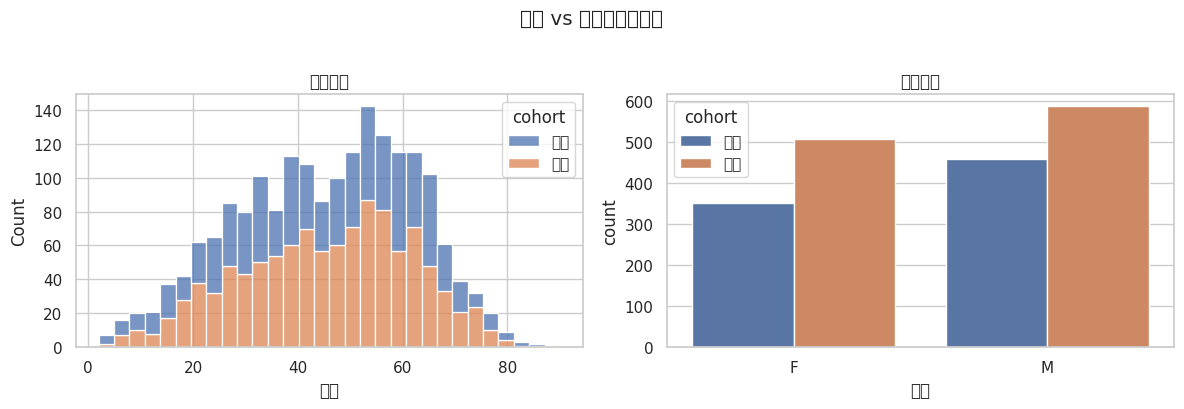

View Position   AP   PA
split cohort           
eval  正常        71  168
      肺炎        95   90
train 正常       281  574
      肺炎       349  277

In [13]:
condition_df = all_df.query("has_pneumonia or is_normal").copy()
condition_df["cohort"] = np.where(condition_df["has_pneumonia"], "肺炎", "正常")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(
    data=condition_df,
    x="Patient Age",
    hue="cohort",
    multiple="stack",
    kde=False,
    bins=30,
    ax=ax[0],
)
ax[0].set_title("年齢分布")
ax[0].set_xlabel("年齢")

sns.countplot(
    data=condition_df,
    x="Patient Gender",
    hue="cohort",
    ax=ax[1],
)
ax[1].set_title("性別内訳")
ax[1].set_xlabel("性別")

plt.suptitle("肺炎 vs 正常の人口統計", y=1.02)
plt.tight_layout()
plt.show()

condition_df.groupby(["split", "cohort", "View Position"]).size().unstack(fill_value=0)


メモ

/tmp/ipykernel_13361/344470141.py:35: UserWarning: Glyph 32954 (\N{CJK UNIFIED IDEOGRAPH-80BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13361/344470141.py:35: UserWarning: Glyph 28814 (\N{CJK UNIFIED IDEOGRAPH-708E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13361/344470141.py:35: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13361/344470141.py:35: UserWarning: Glyph 24120 (\N{CJK UNIFIED IDEOGRAPH-5E38}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13361/344470141.py:35: UserWarning: Glyph 23455 (\N{CJK UNIFIED IDEOGRAPH-5B9F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13361/344470141.py:35: UserWarning: Glyph 30011 (\N{CJK UNIFIED IDEOGRAPH-753B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13361/344470141.py:35: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}

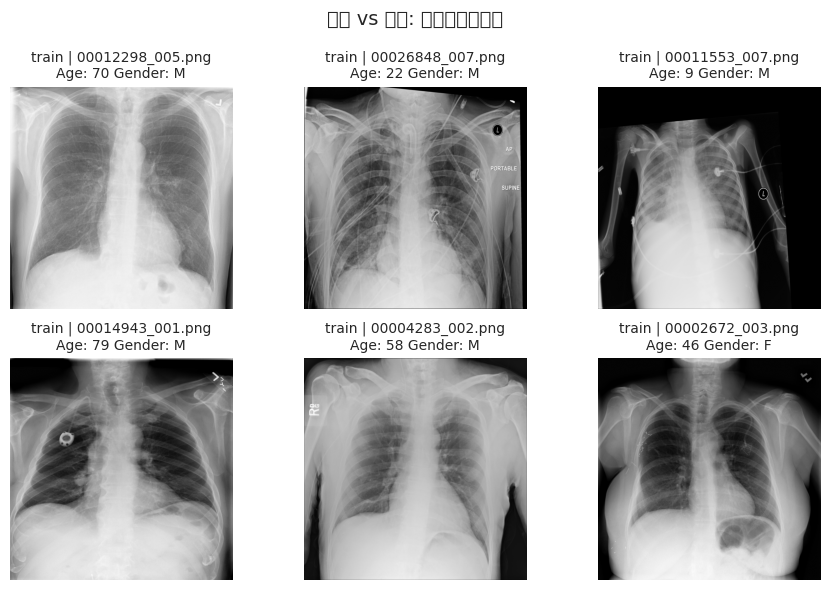

In [17]:
# 肺炎/正常の実際の画像例を表示
example_counts = {"肺炎": 3, "正常": 3}
examples = []
for cohort, count in example_counts.items():
    subset = condition_df.query("cohort == @cohort")
    if subset.empty:
        continue
    sampled = subset.sample(n=min(count, len(subset)), random_state=42)
    examples.append(sampled.assign(example_label=cohort))

if examples:
    example_df = pd.concat(examples, ignore_index=True)
    n_rows = len(example_counts)
    n_cols = max(example_counts.values())
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))
    if n_rows == 1:
        axes = np.array([axes])
    for row_idx, (cohort, count) in enumerate(example_counts.items()):
        cohort_rows = example_df.query("example_label == @cohort").reset_index(drop=True)
        for col_idx in range(n_cols):
            ax = axes[row_idx, col_idx]
            if col_idx < len(cohort_rows):
                row = cohort_rows.iloc[col_idx]
                image_path = SPLITS[row["split"]]["images"] / row["Image Index"]
                img = Image.open(image_path)
                ax.imshow(img, cmap="gray")
                meta = f"{row['split']} | {row['Image Index']}"\
                    f"\nAge: {row['Patient Age']} Gender: {row['Patient Gender']}"
                ax.set_title(meta, fontsize=10)
                ax.axis("off")
            else:
                ax.axis("off")
        axes[row_idx, 0].set_ylabel(cohort, fontsize=12)
    fig.suptitle("肺炎 vs 正常: 実画像サンプル", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("表示できる肺炎/正常サンプルが見つかりませんでした。")
